# Sensitivity tutorial: ERANOS files

This notebook reads the ERANOS ECCO-33 sensitivity file for the ALFRED model.
ERANOS tables are printed in high-to-low group order, while pyNDUS stores the
parsed profiles in ascending energy order.

In [2]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

def find_project_root(start: Path | None = None) -> Path:
    """Find the pyNDUS repository root."""
    start = (start or Path.cwd()).resolve()

    for directory in (start, *start.parents):
        if (
            (directory / "setup.py").is_file()
            and (directory / "src" / "pyNDUS").is_dir()
            and (directory / "docs" / "tutorials").is_dir()
        ):
            return directory

    raise FileNotFoundError(
        f"Could not find the pyNDUS repository root starting from {start}"
    )


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "docs" / "tutorials"
assert DATA_ROOT.exists(), f"Tutorial data directory not found: {DATA_ROOT}"

SENS_ROOT = DATA_ROOT / "MG_sensitivities"
COV_ROOT = DATA_ROOT / "MG_covariances"
assert SENS_ROOT.exists(), SENS_ROOT
assert COV_ROOT.exists(), COV_ROOT

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyNDUS import Sensitivity

In [4]:
eranos_file = SENS_ROOT / "eranos" / "alfred.eranos33"
sens = Sensitivity(eranos_file)

assert sens.reader == "eranos"
assert sens.energy_unit == "eV"
assert sens.n_groups == 33
assert np.all(np.diff(sens.group_structure) > 0.0)
assert sens.sens_rsd is None

print(f"responses: {sens.responses}")
print(f"materials: {len(sens.materials)}")
print(f"nuclides: {len(sens.zais)}")
print(f"MTs: {list(sens.MTs.keys())}")

responses: ('keff',)
materials: 40
nuclides: 545
MTs: [2, 4, 18, 102, 106, 452]


## Metadata overview

In [5]:
pd.DataFrame({
    "materials_sample": list(sens.materials.keys())[:10],
    "nuclides_sample": list(sens.zais.keys())[:10],
})

,materials_sample,nuclides_sample
0,FOOT_I,B-10
1,DIAG_I,B-11
2,FOOT2_I,C-12
3,DIAG2_I,C-13
4,LOCK_I,N-14
5,RACK_I,N-15
6,BPLG_I,O-16
7,PLEN_I,Na-23
8,BINS_I,Mg-24
9,FINN,Mg-25


## Extract a profile

`REACTOR` is the whole-system material summary. The following extraction
retrieves the Pu-239 fission contribution to `keff`.

In [6]:
profile = sens.get(resp="keff", mat="REACTOR", za="Pu-239", MT=18)
profile_desc = sens.get(resp="keff", mat="REACTOR", za="Pu-239", MT=18,
                        group_order="descending",
                        )

assert profile.shape[-1] == sens.n_groups
np.testing.assert_allclose(profile_desc.reshape(-1), profile.reshape(-1)[::-1])

profile_table = pd.DataFrame({
    "E_upper_eV": sens.group_structure[1:],
    "Pu239_MT18_keff": profile.reshape(-1),
})
profile_table.head()

,E_upper_eV,Pu239_MT18_keff
0,0.10000,0.000004
1,0.54000,0.000060
2,4.00000,0.000197
3,8.31529,0.000180
4,13.70960,0.000194


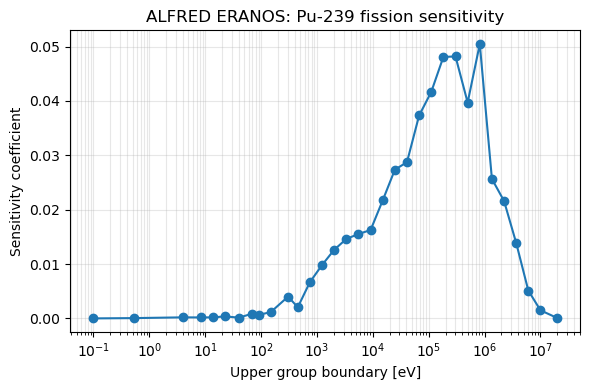

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sens.group_structure[1:], profile.reshape(-1), marker="o")
ax.set_xscale("log")
ax.set_xlabel("Upper group boundary [eV]")
ax.set_ylabel("Sensitivity coefficient")
ax.set_title("ALFRED ERANOS: Pu-239 fission sensitivity")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## Compare domains

In [8]:
domain_norms = []
for material in sens.materials:
    values = sens.get(resp="keff", mat=material, za="Pu-239", MT=18).reshape(-1)
    domain_norms.append((material, float(np.linalg.norm(values))))

domain_table = pd.DataFrame(domain_norms, columns=["material", "profile_norm"]).sort_values(
    "profile_norm", ascending=False,
)
assert domain_table.iloc[0]["profile_norm"] >= 0.0
domain_table.head(10)

,material,profile_norm
39,REACTOR,0.127773
9,FINN,0.075792
23,FOUT,0.052011
30,ZEXT,0.000000
24,TINS_O,0.000000
25,SPRN_O,0.000000
26,TPLG_O,0.000000
27,FUNN_O,0.000000
28,DUMM,0.000000
29,BARL,0.000000
